In [184]:
import pandas as pd
import requests
import time
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import geopandas as gpd
import geodatasets

In [4]:
entrepreneurs = pd.read_excel('./data/реестр_предпринимателей.xlsx', sheet_name='Лист1', skiprows=2)
entrepreneurs.head()

/home/yn/Documents/Python/test/.venv/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,№ п/п,Наименование / ФИО,Тип субъекта,Категория,ОГРН,ИНН,Основной вид деятельности,Регион,Район,Город,...,Дата исключения из реестра,Телефон,E-mail,WWW,Наличие лицензий,"Наличие заключенных договоров, контрактов","Производство инновационной, высокотехнологичной продукции",Участие в программах партнерства,Является социальным предприятием,Среднесписочная численность работников за предшествующий календарный год
0,1,""" МЕГАПОЛИС "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВ...",Юридическое лицо,Не является субъектом МСП,1027800523376,7801190028,41.2 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,10.10.2021,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
1,2,""" СТАЛЬИНВЕСТСТРОЙ "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ О...",Юридическое лицо,Не является субъектом МСП,1037800033545,7801227976,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,10.08.2018,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
2,3,""" СТРОЙТЕХНИКА - М "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ О...",Юридическое лицо,Не является субъектом МСП,1025204418293,5263039399,41.20 Строительство жилых и нежилых зданий,52 - Нижегородская область,NaN,г Нижний Новгород,...,10.07.2022,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
3,4,"""БАЗИС"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ",Юридическое лицо,Микропредприятие,1025204411682,5263025484,41.20 Строительство жилых и нежилых зданий,52 - Нижегородская область,NaN,г Нижний Новгород,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,1.0
4,5,"""БЕЛАГ"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ",Юридическое лицо,Не является субъектом МСП,1037800039276,7801123215,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,10.07.2021,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN


In [5]:
entrepreneurs.drop("№ п/п", axis=1, inplace=True)

In [6]:
type_mask = (
    (entrepreneurs['Тип субъекта'] == 'Юридическое лицо') & 
    (entrepreneurs['Категория'].isin(['Малое предприятие', 'Среднее предприятие'])) &
    (entrepreneurs['Основной вид деятельности'] == '41.20 Строительство жилых и нежилых зданий')
)

entrepreneurs = entrepreneurs[type_mask]
entrepreneurs_names = entrepreneurs[['Наименование / ФИО', 'ИНН']].reset_index().drop('index', axis=1)
entrepreneurs_names = entrepreneurs_names[0:1500]
entrepreneurs_names

,Наименование / ФИО,ИНН
0,"""КОРПОРАЦИЯ ВИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕ...",5038038838
1,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",5027006369
2,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""",1414006922
3,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АГРОТЕХИМПОРТ""",3327332190
4,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АКС""",7816061297
...,...,...
1495,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ГАРА...",7723882491
1496,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ГАРА...",5009122179
1497,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ГАРА...",2508125846
1498,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ГАРА...",1650359769


In [ ]:
def get_company_ebitda(inn, session):
    try:
        search_url = f'https://bo.nalog.gov.ru/advanced-search/organizations/search?query={inn}&page=0'
        res = session.get(search_url).json()
        
        if not res['content']:
            return {"ИНН": inn, "Статус": "Не найден"}
        
        org_id = res['content'][0]['id']
        
        bfo = session.get(f'https://bo.nalog.gov.ru/nbo/organizations/{org_id}/bfo').json()
        
        latest_report = bfo[0]['typeCorrections'][0]['correction']

        address = latest_report['bfoOrganizationInfo'].get('address')
        
        fin_res = latest_report.get('financialResult', {})
        balance = latest_report.get('balance', {})
        
        c_2400 = fin_res.get('current2400') or 0  
        p_2400 = fin_res.get('previous2400') or 0  
        c_2410 = fin_res.get('current2410') or 0  
        c_2330 = fin_res.get('current2330') or 0 
        
        os_end = balance.get('current1150') or 0
        os_start = balance.get('previous1150') or 0
        depreciation = max(0, os_start - os_end) 
        
        ebitda = c_2400 + c_2410 + c_2330 + depreciation
        
        return {
            "ИНН": inn,
            "Адрес": address,
            "Чистая прибыль (2400)": c_2400,
            "Чистая прибыль прошлый год (2400)": p_2400,
            "Налоги (2410)": c_2410,
            "Проценты (2330)": c_2330,
            "Амортизация (расчетная)": depreciation,
            "EBITDA": ebitda
        }
    
    except Exception as e:
        return {"ИНН": inn, "Статус": f"Ошибка: {str(e)}"}


In [9]:
session = requests.Session()
session.headers.update({
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/121.0.0.0 Safari/537.36',
    'Accept': 'application/json, text/plain, */*',
    'Referer': 'https://bo.nalog.ru/'
})

inns = entrepreneurs_names['ИНН']
parsed_results = []

for inn in tqdm(inns, desc="Парсим ИНН", unit='company'):
    data = get_company_ebitda(inn, session)
    parsed_results.append(data)
    time.sleep(random.randint(5, 15) / 10) 

parsed_df = pd.DataFrame(parsed_results)
entrepreneurs_final_data = entrepreneurs_names.merge(parsed_df, left_on='ИНН', right_on='ИНН', how='left')
entrepreneurs_final_data

Парсим ИНН: 100%|██████████| 1500/1500 [27:32<00:00,  1.10s/company]


,Наименование / ФИО,ИНН,Адрес,Чистая прибыль (2400),Чистая прибыль прошлый год (2400),Налоги (2410),Проценты (2330),Амортизация (расчетная),EBITDA,Статус
0,"""КОРПОРАЦИЯ ВИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕ...",5038038838,"141207, Московская обл, г Пушкино, ул Чехова, ...",-20129.0,-20913.0,-191.0,1521.0,0.0,-18799.0,NaN
1,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",5027006369,"140093, Московская обл, Дзержинский г, Угрешск...",28998.0,582441.0,-8184.0,705.0,0.0,21519.0,NaN
2,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""",1414006922,"678144, Саха /Якутия/ респ, Ленский муниципаль...",54850.0,19889.0,-16937.0,0.0,0.0,37913.0,NaN
3,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АГРОТЕХИМПОРТ""",3327332190,"Владимир г, Александра Матросова ул, 1, 600005",47723.0,40101.0,-13461.0,0.0,0.0,34262.0,NaN
4,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АКС""",7816061297,"192102, Город Санкт-Петербург, вн.тер. г. Муни...",11674.0,565.0,2975.0,0.0,0.0,14649.0,NaN
...,...,...,...,...,...,...,...,...,...,...
1495,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ГАРА...",7723882491,"125480, Москва г, Вилиса Лациса ул, дом № 11, ...",19033.0,26900.0,-4952.0,0.0,1183.0,15264.0,NaN
1496,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ГАРА...",5009122179,"142002, Московская обл, Домодедово г, Текстиль...",-7703.0,228.0,0.0,0.0,0.0,-7703.0,NaN
1497,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ГАРА...",2508125846,"692910, Приморский край, г Находка, ул Пограни...",13396.0,8059.0,4269.0,0.0,19799.0,37464.0,NaN
1498,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ГАРА...",1650359769,"423827, Татарстан Респ, г.о. город Набережные ...",2861.0,7462.0,-1146.0,0.0,2218.0,3933.0,NaN


In [10]:
entrepreneurs_final_data.to_csv('./data/данные_предпринимателей.csv') 

In [11]:
entrepreneurs_final_data = entrepreneurs_final_data[entrepreneurs_final_data['Статус'].isna()]
entrepreneurs_final_data = entrepreneurs_final_data.reset_index().drop('index',  axis=1)
entrepreneurs_final_data = entrepreneurs_final_data.drop('Статус', axis=1)
entrepreneurs_final_data

,Наименование / ФИО,ИНН,Адрес,Чистая прибыль (2400),Чистая прибыль прошлый год (2400),Налоги (2410),Проценты (2330),Амортизация (расчетная),EBITDA
0,"""КОРПОРАЦИЯ ВИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕ...",5038038838,"141207, Московская обл, г Пушкино, ул Чехова, ...",-20129.0,-20913.0,-191.0,1521.0,0.0,-18799.0
1,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",5027006369,"140093, Московская обл, Дзержинский г, Угрешск...",28998.0,582441.0,-8184.0,705.0,0.0,21519.0
2,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""",1414006922,"678144, Саха /Якутия/ респ, Ленский муниципаль...",54850.0,19889.0,-16937.0,0.0,0.0,37913.0
3,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АГРОТЕХИМПОРТ""",3327332190,"Владимир г, Александра Матросова ул, 1, 600005",47723.0,40101.0,-13461.0,0.0,0.0,34262.0
4,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АКС""",7816061297,"192102, Город Санкт-Петербург, вн.тер. г. Муни...",11674.0,565.0,2975.0,0.0,0.0,14649.0
...,...,...,...,...,...,...,...,...,...
1482,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ГАРА...",7723882491,"125480, Москва г, Вилиса Лациса ул, дом № 11, ...",19033.0,26900.0,-4952.0,0.0,1183.0,15264.0
1483,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ГАРА...",5009122179,"142002, Московская обл, Домодедово г, Текстиль...",-7703.0,228.0,0.0,0.0,0.0,-7703.0
1484,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ГАРА...",2508125846,"692910, Приморский край, г Находка, ул Пограни...",13396.0,8059.0,4269.0,0.0,19799.0,37464.0
1485,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ГАРА...",1650359769,"423827, Татарстан Респ, г.о. город Набережные ...",2861.0,7462.0,-1146.0,0.0,2218.0,3933.0


In [52]:
condition = entrepreneurs_final_data['Чистая прибыль прошлый год (2400)'] != 0

entrepreneurs_final_data['Процент роста прибыли'] = (
    (entrepreneurs_final_data['Чистая прибыль (2400)'] / 
     entrepreneurs_final_data['Чистая прибыль прошлый год (2400)'])
    .where(condition, 0) 
) * 100

entrepreneurs_final_data['Процент роста прибыли'] = entrepreneurs_final_data['Процент роста прибыли'].astype(int)
entrepreneurs_final_data

,Наименование / ФИО,ИНН,Адрес,Чистая прибыль (2400),Чистая прибыль прошлый год (2400),Налоги (2410),Проценты (2330),Амортизация (расчетная),EBITDA,Процент роста прибыли
0,"""КОРПОРАЦИЯ ВИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕ...",5038038838,"141207, Московская обл, г Пушкино, ул Чехова, ...",-20129.0,-20913.0,-191.0,1521.0,0.0,-18799.0,96
1,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",5027006369,"140093, Московская обл, Дзержинский г, Угрешск...",28998.0,582441.0,-8184.0,705.0,0.0,21519.0,4
2,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""",1414006922,"678144, Саха /Якутия/ респ, Ленский муниципаль...",54850.0,19889.0,-16937.0,0.0,0.0,37913.0,275
3,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АГРОТЕХИМПОРТ""",3327332190,"Владимир г, Александра Матросова ул, 1, 600005",47723.0,40101.0,-13461.0,0.0,0.0,34262.0,119
4,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АКС""",7816061297,"192102, Город Санкт-Петербург, вн.тер. г. Муни...",11674.0,565.0,2975.0,0.0,0.0,14649.0,2066
...,...,...,...,...,...,...,...,...,...,...
1482,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ГАРА...",7723882491,"125480, Москва г, Вилиса Лациса ул, дом № 11, ...",19033.0,26900.0,-4952.0,0.0,1183.0,15264.0,70
1483,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ГАРА...",5009122179,"142002, Московская обл, Домодедово г, Текстиль...",-7703.0,228.0,0.0,0.0,0.0,-7703.0,-3378
1484,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ГАРА...",2508125846,"692910, Приморский край, г Находка, ул Пограни...",13396.0,8059.0,4269.0,0.0,19799.0,37464.0,166
1485,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ГАРА...",1650359769,"423827, Татарстан Респ, г.о. город Набережные ...",2861.0,7462.0,-1146.0,0.0,2218.0,3933.0,38


In [102]:
entrepreneurs_final_data['Процент роста прибыли'].quantile([0.25, 0.50, 0.75])

0.25      0.0
0.50     62.0
0.75    172.5
Name: Процент роста прибыли, dtype: float64

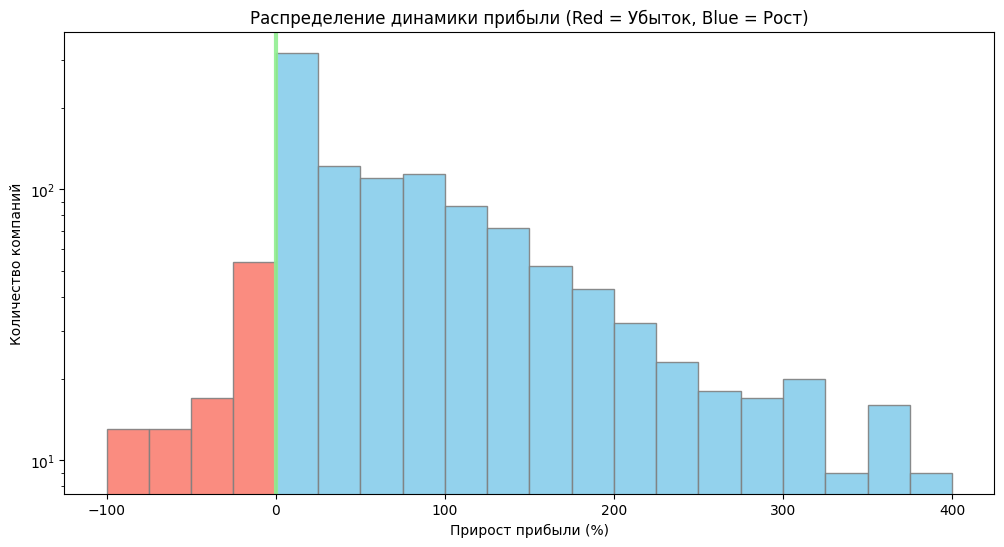

In [103]:
plt.figure(figsize=(12, 6))
n, bins, patches = plt.hist(entrepreneurs_final_data['Процент роста прибыли'], 
                            bins=20, range=[-100, 400], 
                            color='skyblue', edgecolor='grey', alpha=0.9, log=True)

for i, bar in enumerate(patches):
    if bins[i] < 0:
        bar.set_facecolor('salmon')

plt.axvline(0, color='lightgreen', linewidth=3, alpha=0.9)
plt.title('Распределение динамики прибыли (Red = Убыток, Blue = Рост)')
plt.xlabel('Прирост прибыли (%)')
plt.ylabel('Количество компаний')
plt.show()

## Вывод
Рынок строительного бизнеса 2024 года демонстрирует увеличение прибыли по сравнению с 2023 годом. Большая часть компаний показывает рост от 5% до 200%, однако значительная часть вовсе не прогрессирует. Основной массив данных сосредоточен в зоне умеренного роста до 50%. Также стоит отметить, что зона убыточных компаний составляет около 1/5 от общей массы, поэтому определенные риски выхода на рынок несомненно есть

In [200]:
top_500 = entrepreneurs_final_data.sort_values(by='Чистая прибыль (2400)', ascending=False)
top_500 = top_500.reset_index().drop('index', axis=1)[:500]
top_500


,Наименование / ФИО,ИНН,Адрес,Чистая прибыль (2400),Чистая прибыль прошлый год (2400),Налоги (2410),Проценты (2330),Амортизация (расчетная),EBITDA,Процент роста прибыли
0,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""МР-ЦЕНТР""",9715426146,"127015, Москва г, ул Новодмитровская, д 2, к 2...",2206425.0,785040.0,-555559.0,0.0,0.0,1650866.0,281
1,"ЗАКРЫТОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""СТРОИТЕЛЬНАЯ КО...",7806056530,"193318, Санкт-Петербург г, Бадаева ул, дом 8, ...",2145252.0,-15317.0,-715037.0,0.0,0.0,1430215.0,-14005
2,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АРСЕ...",4703142292,"188660, Ленинградская обл., Всеволожский р-н, ...",1144304.0,1272536.0,-285276.0,0.0,470611.0,1329639.0,89
3,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""ТЕПЛОИНДУСТРИЯ""",7712103721,"107061, Москва г, ул Хромова, д 20",1013637.0,50684.0,-166606.0,0.0,0.0,847031.0,1999
4,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""СПЕЦИАЛИЗИРОВАННЫЙ ЗАСТР...",1001010821,"185000, Карелия Респ, г Петрозаводск, пр-кт Пе...",939525.0,870349.0,-237288.0,28993.0,0.0,731230.0,107
...,...,...,...,...,...,...,...,...,...,...
495,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""БАЗА...",7727573906,"125239, Москва г, Коптевская ул, дом 73А, стро...",5456.0,-7195.0,-1366.0,557.0,0.0,4647.0,-75
496,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ВГ Г...",7751030033,"108811, Город Москва, вн.тер. г. Поселение Мос...",5422.0,2706.0,-1356.0,0.0,0.0,4066.0,200
497,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""БАЛТ...",3912000363,"238563, Калининградская обл, р-н Светлогорский...",5416.0,162.0,-346.0,6.0,12.0,5088.0,3343
498,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ВЕСТ...",7810391877,"192236, город Санкт-Петербург, ул Софийская, д...",5387.0,303.0,40.0,25.0,1523.0,6975.0,1777


In [202]:
def get_structured_address(inn, session):
    try:
        search_url = f'https://bo.nalog.gov.ru/advanced-search/organizations/search?query={inn}&page=0'
        res = session.get(search_url).json()
        
        if not res['content']:
            return {"ИНН": inn, "Чистый_Адрес": None}
        
        org = res['content'][0]
        
        address_parts = []
        if org.get('region'): address_parts.append(org['region'])
        if org.get('city'): address_parts.append(org['city'])
        if org.get('street'): address_parts.append(org['street'])
        if org.get('house'): address_parts.append(org['house'])
        
        full_address = ", ".join([str(p).title() if isinstance(p, str) else str(p) for p in address_parts])
        
        return {
            "ИНН": inn,
            "Чистый_Адрес": full_address
        }
        
    except Exception as e:
        return {"ИНН": inn, "Чистый_Адрес": f"Ошибка: {str(e)}"}


top_inns = top_500['ИНН'].tolist()
address_results = []

for inn in tqdm(top_inns, desc="Получаем чистые адреса", unit='company'):
    addr_data = get_structured_address(inn, session)
    address_results.append(addr_data)
    time.sleep(random.randint(5, 12) / 10) 

df_addresses = pd.DataFrame(address_results)

top_500 = top_500.merge(df_addresses, on='ИНН', how='left')
top_500

Получаем чистые адреса: 100%|██████████| 500/500 [07:26<00:00,  1.12company/s]


,Наименование / ФИО,ИНН,Адрес,Чистая прибыль (2400),Чистая прибыль прошлый год (2400),Налоги (2410),Проценты (2330),Амортизация (расчетная),EBITDA,Процент роста прибыли,Чистый_Адрес
0,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""МР-ЦЕНТР""",9715426146,"127015, Москва г, ул Новодмитровская, д 2, к 2...",2206425.0,785040.0,-555559.0,0.0,0.0,1650866.0,281,"Москва, Новодмитровская, 2"
1,"ЗАКРЫТОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""СТРОИТЕЛЬНАЯ КО...",7806056530,"193318, Санкт-Петербург г, Бадаева ул, дом 8, ...",2145252.0,-15317.0,-715037.0,0.0,0.0,1430215.0,-14005,"Санкт-Петербург, Бадаева, 8"
2,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АРСЕ...",4703142292,"188660, Ленинградская обл., Всеволожский р-н, ...",1144304.0,1272536.0,-285276.0,0.0,470611.0,1329639.0,89,"Санкт-Петербург, Плесецкая, 2"
3,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""ТЕПЛОИНДУСТРИЯ""",7712103721,"107061, Москва г, ул Хромова, д 20",1013637.0,50684.0,-166606.0,0.0,0.0,847031.0,1999,"Москва, Хромова, 20"
4,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""СПЕЦИАЛИЗИРОВАННЫЙ ЗАСТР...",1001010821,"185000, Карелия Респ, г Петрозаводск, пр-кт Пе...",939525.0,870349.0,-237288.0,28993.0,0.0,731230.0,107,"Карелия, Петрозаводск, Первомайский, 43"
...,...,...,...,...,...,...,...,...,...,...,...
495,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""БАЗА...",7727573906,"125239, Москва г, Коптевская ул, дом 73А, стро...",5456.0,-7195.0,-1366.0,557.0,0.0,4647.0,-75,"Москва, Коптевская, 73А"
496,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ВГ Г...",7751030033,"108811, Город Москва, вн.тер. г. Поселение Мос...",5422.0,2706.0,-1356.0,0.0,0.0,4066.0,200,"Москва, 22-Й, 4"
497,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""БАЛТ...",3912000363,"238563, Калининградская обл, р-н Светлогорский...",5416.0,162.0,-346.0,6.0,12.0,5088.0,3343,"Калининградская, Светлогорск, Железнодорожная, 1А"
498,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ВЕСТ...",7810391877,"192236, город Санкт-Петербург, ул Софийская, д...",5387.0,303.0,40.0,25.0,1523.0,6975.0,1777,"Санкт-Петербург, Софийская, 14"


In [203]:
top_500.isna().sum()

Наименование / ФИО                   0
ИНН                                  0
Адрес                                0
Чистая прибыль (2400)                0
Чистая прибыль прошлый год (2400)    0
Налоги (2410)                        0
Проценты (2330)                      0
Амортизация (расчетная)              0
EBITDA                               0
Процент роста прибыли                0
Чистый_Адрес                         0
dtype: int64

In [204]:

geolocator = Nominatim(user_agent="my_request")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

top_500['location'] = top_500['Чистый_Адрес'].apply(geocode)

top_500['lat'] = top_500['location'].apply(lambda loc: loc.latitude if loc else None)
top_500['lon'] = top_500['location'].apply(lambda loc: loc.longitude if loc else None)

top_500 = top_500.dropna(subset=['lat', 'lon'])
top_500


RateLimiter caught an error, retrying (0/2 tries). Called with (*('Московская, 34',), **{}).
Traceback (most recent call last):
  File "/home/yn/Documents/Python/test/.venv/lib/python3.13/site-packages/urllib3/connectionpool.py", line 534, in _make_request
    response = conn.getresponse()
  File "/home/yn/Documents/Python/test/.venv/lib/python3.13/site-packages/urllib3/connection.py", line 571, in getresponse
    httplib_response = super().getresponse()
  File "/usr/lib/python3.13/http/client.py", line 1450, in getresponse
    response.begin()
    ~~~~~~~~~~~~~~^^
  File "/usr/lib/python3.13/http/client.py", line 336, in begin
    version, status, reason = self._read_status()
                              ~~~~~~~~~~~~~~~~~^^
  File "/usr/lib/python3.13/http/client.py", line 297, in _read_status
    line = str(self.fp.readline(_MAXLINE + 1), "iso-8859-1")
               ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^
  File "/usr/lib/python3.13/socket.py", line 719, in readinto
    return self._sock.re

,Наименование / ФИО,ИНН,Адрес,Чистая прибыль (2400),Чистая прибыль прошлый год (2400),Налоги (2410),Проценты (2330),Амортизация (расчетная),EBITDA,Процент роста прибыли,Чистый_Адрес,location,lat,lon
0,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""МР-ЦЕНТР""",9715426146,"127015, Москва г, ул Новодмитровская, д 2, к 2...",2206425.0,785040.0,-555559.0,0.0,0.0,1650866.0,281,"Москва, Новодмитровская, 2","(Причал Моряка, 1/2, Новодмитровская улица, Бу...",55.806420,37.585182
1,"ЗАКРЫТОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""СТРОИТЕЛЬНАЯ КО...",7806056530,"193318, Санкт-Петербург г, Бадаева ул, дом 8, ...",2145252.0,-15317.0,-715037.0,0.0,0.0,1430215.0,-14005,"Санкт-Петербург, Бадаева, 8","(8 к1, улица Бадаева, округ Правобережный, Сан...",59.917930,30.449242
2,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АРСЕ...",4703142292,"188660, Ленинградская обл., Всеволожский р-н, ...",1144304.0,1272536.0,-285276.0,0.0,470611.0,1329639.0,89,"Санкт-Петербург, Плесецкая, 2","(2 с1, Плесецкая улица, округ Юнтолово, Санкт-...",60.029795,30.206368
3,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""ТЕПЛОИНДУСТРИЯ""",7712103721,"107061, Москва г, ул Хромова, д 20",1013637.0,50684.0,-166606.0,0.0,0.0,847031.0,1999,"Москва, Хромова, 20","(20, улица Хромова, Черкизово, район Преображе...",55.799787,37.718360
4,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""СПЕЦИАЛИЗИРОВАННЫЙ ЗАСТР...",1001010821,"185000, Карелия Респ, г Петрозаводск, пр-кт Пе...",939525.0,870349.0,-237288.0,28993.0,0.0,731230.0,107,"Карелия, Петрозаводск, Первомайский, 43","(ВЕК, 43, Первомайский проспект, Первомайский,...",61.797737,34.330906
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""БАЗА...",7727573906,"125239, Москва г, Коптевская ул, дом 73А, стро...",5456.0,-7195.0,-1366.0,557.0,0.0,4647.0,-75,"Москва, Коптевская, 73А","(73А с7, Коптевская улица, район Коптево, Моск...",55.832734,37.517141
496,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ВГ Г...",7751030033,"108811, Город Москва, вн.тер. г. Поселение Мос...",5422.0,2706.0,-1356.0,0.0,0.0,4066.0,200,"Москва, 22-Й, 4","(4, 22-й квартал, Гаврилково, городской округ ...",55.876865,37.364690
497,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""БАЛТ...",3912000363,"238563, Калининградская обл, р-н Светлогорский...",5416.0,162.0,-346.0,6.0,12.0,5088.0,3343,"Калининградская, Светлогорск, Железнодорожная, 1А","(1А к1, Железнодорожная улица, Сельский, Светл...",54.934212,20.166747
498,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ВЕСТ...",7810391877,"192236, город Санкт-Петербург, ул Софийская, д...",5387.0,303.0,40.0,25.0,1523.0,6975.0,1777,"Санкт-Петербург, Софийская, 14","(Бизнес-парк «Софийская 14», 14, Софийская ули...",59.880845,30.394582


(40.0, 85.0)

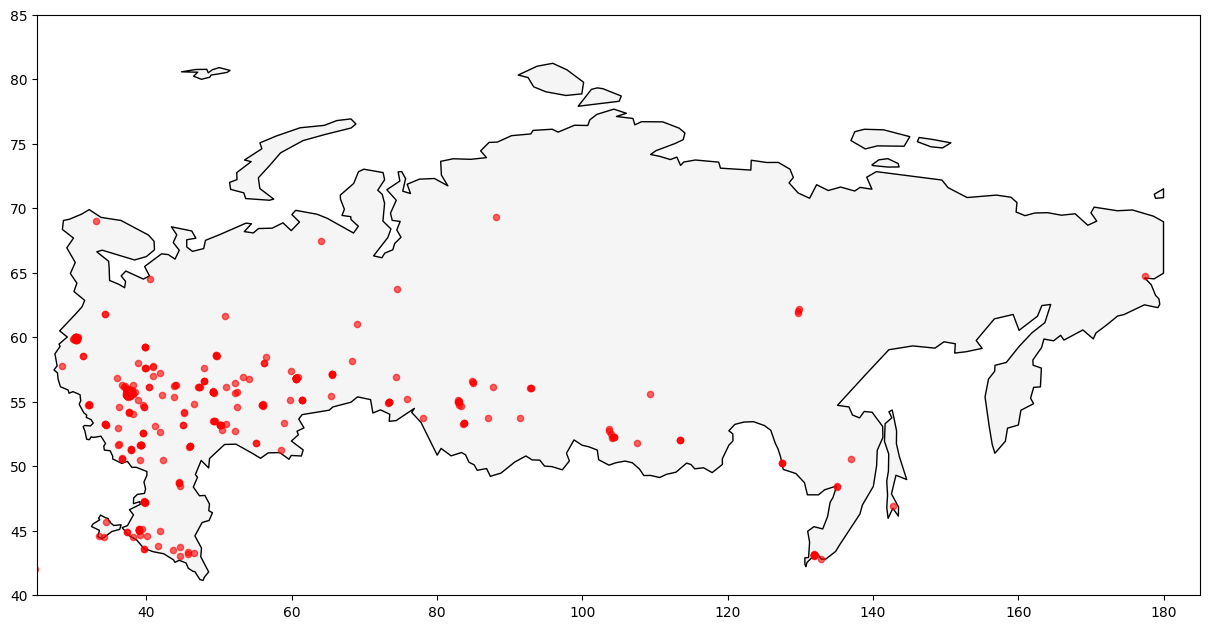

In [210]:
gdf = gpd.GeoDataFrame(
    top_500, 
    geometry=gpd.points_from_xy(top_500.lon, top_500.lat),
    crs="EPSG:4326"
)

url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
russia = world[world.ADMIN == "Russia"]

ax = russia.plot(figsize=(15, 10), color='whitesmoke', edgecolor='black')
gdf.plot(ax=ax, color='red', markersize=20, alpha=0.6)
ax.set_xlim([25, 185]) 
ax.set_ylim([40, 85])